In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

from ryrMC import *
from params import RestrepoParams
#from utils import _rho, _Mhat

# Experiment to see effect of reflecting boundaries

### $N=100$

In [2]:
cs = 0.2
cjsr = 1100.
params = RestrepoParams(Ku=1.4e-4, h=2.5)

N = 100

Pos = np.arange(0, N+1)
log_pi = Po_stationary_logp(N, cs, cjsr, params)

# Most of the invariant distribution mass is at large values of Po, so have to truncate to observe the behaviour near 0.
# Here I am just truncating at the value of lowest probability
truncate = np.argmin(log_pi)
log_pi_tr = Po_stationary_logp(N, cs, cjsr, params, truncate=truncate)

kr = params.tau_ps * params.Jmax / params.vp

# Get the fixed points, the Jacobians at the fixed points and the diffusion matrix at the fixed points
fixed_pts = fixed_points_and_jac(cs, cjsr, eps=1/np.sqrt(N), params=params)
# Solve the Riccati equation BJ + JB^T = ΣΣ^T, which gives the covariance B of the stationary OU process
cov = solve_riccati(-fixed_pts[1]['jacobian'], fixed_pts[1]['Sigma'])

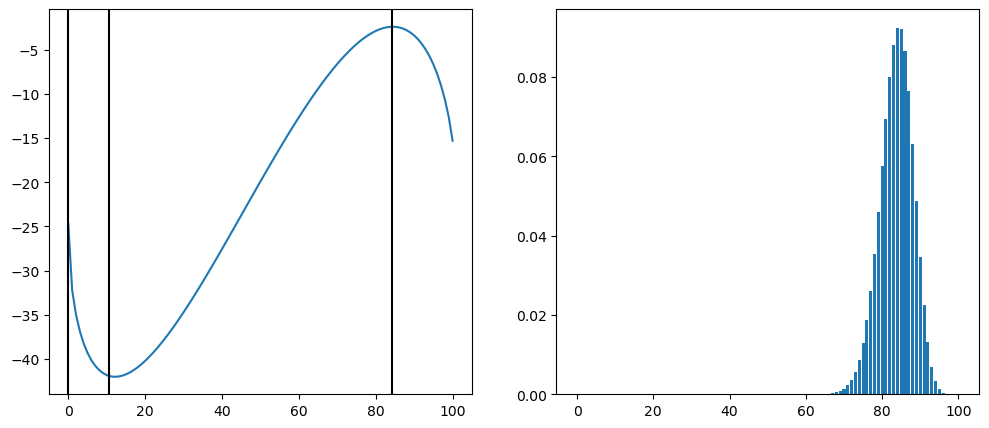

In [3]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(Pos, log_pi)
ax[0].axvline(x=fixed_pts[1]['fp'][1:].sum()*N, color='k')
ax[0].axvline(x=fixed_pts[2]['fp'][1:].sum()*N, color='k')
ax[0].axvline(x=fixed_pts[3]['fp'][1:].sum()*N, color='k')
ax[1].bar(Pos, np.exp(log_pi))
plt.show()

In [4]:
S = np.linalg.cholesky(cov)
normals = np.random.normal(size=(3, 1_000_000))
stationary = fixed_pts[1]['fp'].reshape(-1, 1) + S @ normals

# The stationary relfected OU process is just the same Gaussian truncated to the appropriate domain
bdy_idx = np.where((stationary.sum(axis=0) <= 1) * (stationary[0, :] <= 1) * (stationary[1, :] >= 0) * (stationary[2, :] >= 0))[0]

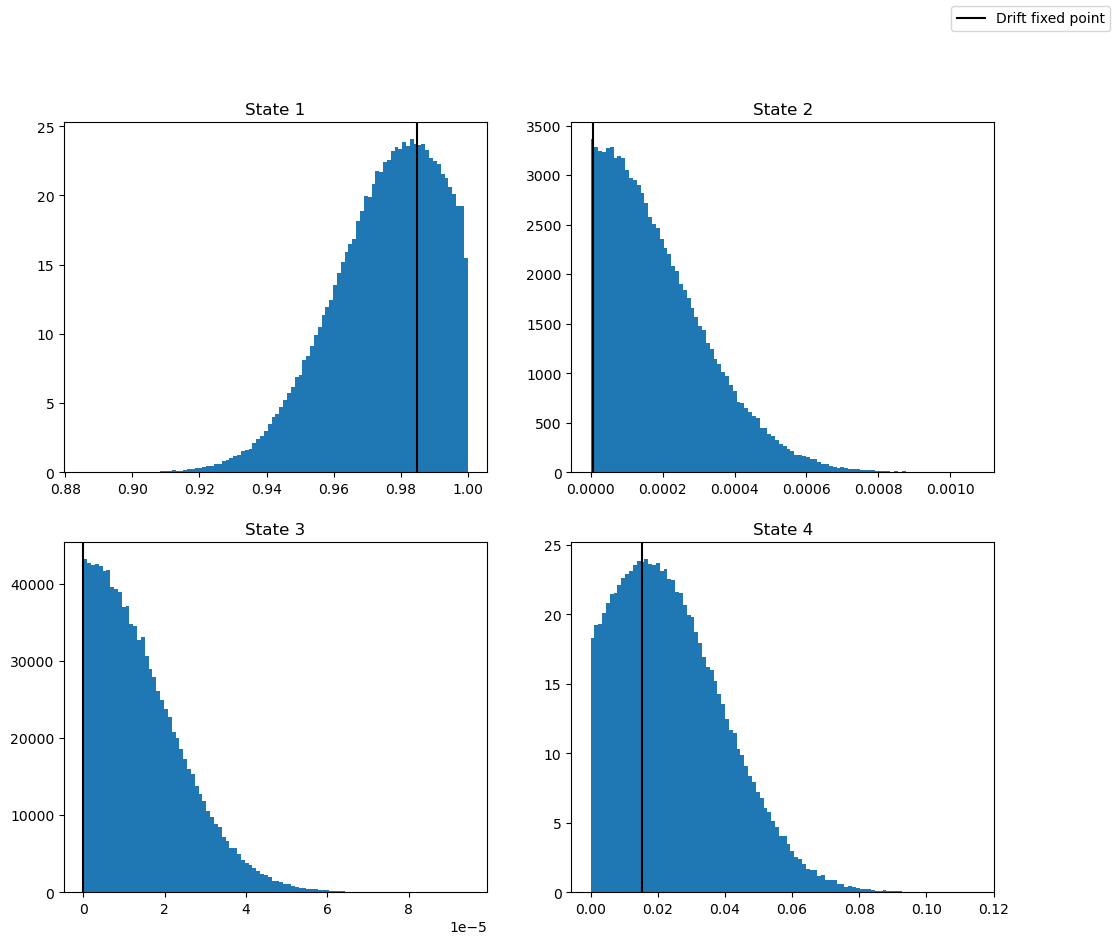

In [5]:
fig, ax = plt.subplots(2,2, figsize=(12,10))
ax[0,0].hist(stationary[0, bdy_idx], bins=100, density=True)
ax[0,0].axvline(x=fixed_pts[1]['fp'][0], color='k', label="Drift fixed point")
ax[0,0].set_title("State 1")

ax[0,1].hist(stationary[1, bdy_idx], bins=100, density=True)
ax[0,1].axvline(x=fixed_pts[1]['fp'][1], color='k')
ax[0,1].set_title("State 2")

ax[1,0].hist(stationary[2, bdy_idx], bins=100, density=True)
ax[1,0].axvline(x=fixed_pts[1]['fp'][2], color='k')
ax[1,0].set_title("State 3")

ax[1,1].hist(1 - stationary[:, bdy_idx].sum(axis=0), bins=100, density=True)
ax[1,1].axvline(x=1-fixed_pts[1]['fp'].sum(), color='k')
ax[1,1].set_title("State 4")
fig.legend()
plt.show()

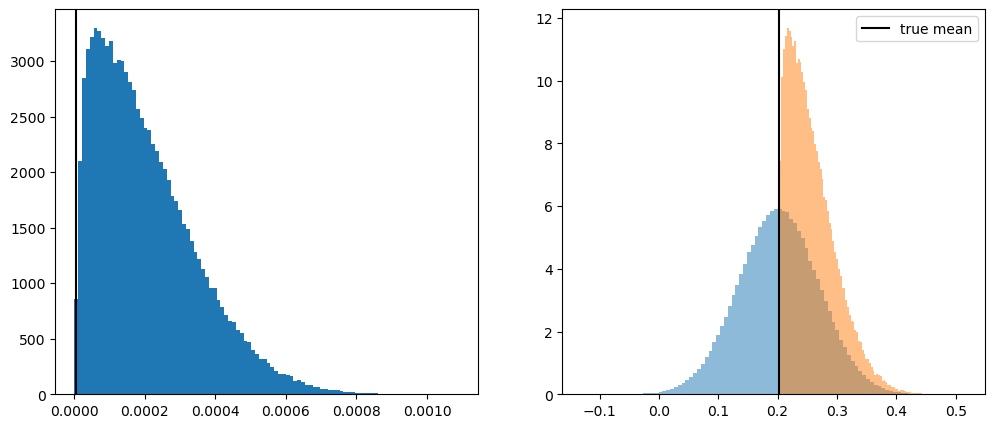

In [6]:
cp_no_boundary = (cs + kr * cjsr * stationary[1:].sum(axis=0)) / (1 + kr * stationary[1:].sum(axis=0))
cp_boundary = (cs + kr * cjsr * stationary[1:, bdy_idx].sum(axis=0)) / (1 + kr * stationary[1:, bdy_idx].sum(axis=0))
cp_true = (cs + kr * cjsr * np.arange(0, len(log_pi_tr)) / N) / (1 + kr * np.arange(0, len(log_pi_tr)) / N)

true_mean = (cp_true * np.exp(log_pi_tr)).sum()

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].hist(stationary[1, bdy_idx] + stationary[2, bdy_idx], bins=100, density=True)
ax[0].axvline(x=fixed_pts[1]['fp'][1] + fixed_pts[1]['fp'][2], color='k')

ax[1].hist(cp_no_boundary, density=True, bins=100, alpha=0.5)
ax[1].hist(cp_boundary, density=True, bins=100, alpha=0.5)
ax[1].axvline(x=true_mean, color='k', label="true mean")
ax[1].legend()
plt.show()

In [7]:
true_std = np.sqrt((cp_true**2 * np.exp(log_pi_tr)).sum() - true_mean**2)
print(f"Mean no boundary imposed: {cp_no_boundary.mean()},  relative error: {(cp_no_boundary.mean() - true_mean) / true_mean}")
print(f"Mean boundary imposed: {cp_boundary.mean()}, relative error: {(cp_boundary.mean() - true_mean) / true_mean}")
print(f"\nStd. dev no boundary imposed: {cp_no_boundary.std()},  relative error: {(cp_no_boundary.std() - true_std) / true_std}")
print(f"Std. dev boundary imposed: {cp_boundary.std()}, relative error: {(cp_boundary.std() - true_std) / true_std}")

Mean no boundary imposed: 0.20162952047497865,  relative error: -0.0009992273905734255
Mean boundary imposed: 0.2580890579934818, relative error: 0.2787371994445782

Std. dev no boundary imposed: 0.06750612161077166,  relative error: -0.15310992377472893
Std. dev boundary imposed: 0.040937372445465726, relative error: -0.4864250286707224


### $N = 1000$

In [8]:
N = 1000

Pos = np.arange(0, N+1)
log_pi = Po_stationary_logp(N, cs, cjsr, params)

truncate = np.argmin(log_pi)
log_pi_tr = Po_stationary_logp(N, cs, cjsr, params, truncate=truncate)


fixed_pts = fixed_points_and_jac(cs, cjsr, eps=1/np.sqrt(N), params=params)
cov = solve_riccati(-fixed_pts[1]['jacobian'], fixed_pts[1]['Sigma'])

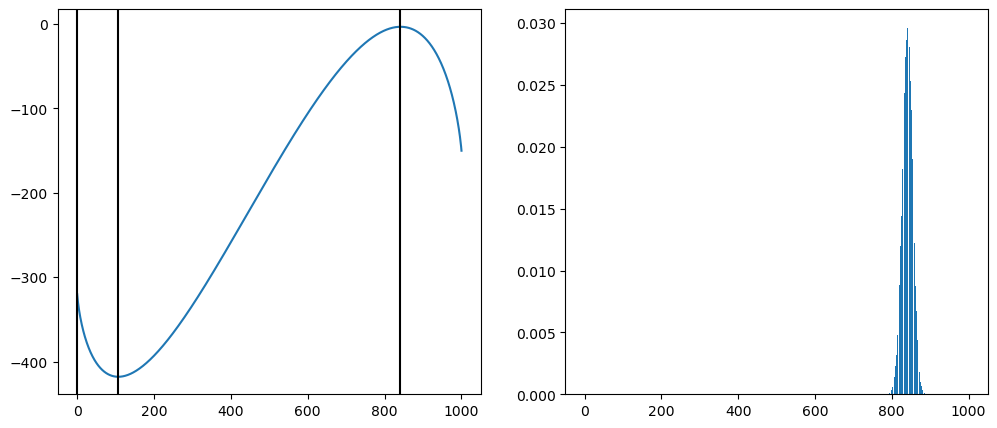

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(Pos, log_pi)
ax[0].axvline(x=fixed_pts[1]['fp'][1:].sum()*N, color='k')
ax[0].axvline(x=fixed_pts[2]['fp'][1:].sum()*N, color='k')
ax[0].axvline(x=fixed_pts[3]['fp'][1:].sum()*N, color='k')
ax[1].bar(Pos, np.exp(log_pi))
plt.show()

In [10]:
S = np.linalg.cholesky(cov)
normals = np.random.normal(size=(3, 1_000_000))
stationary = fixed_pts[1]['fp'].reshape(-1, 1) + S @ normals
bdy_idx = np.where((stationary.sum(axis=0) <= 1) * (stationary[0, :] <= 1) * (stationary[1, :] >= 0) * (stationary[2, :] >= 0))[0]

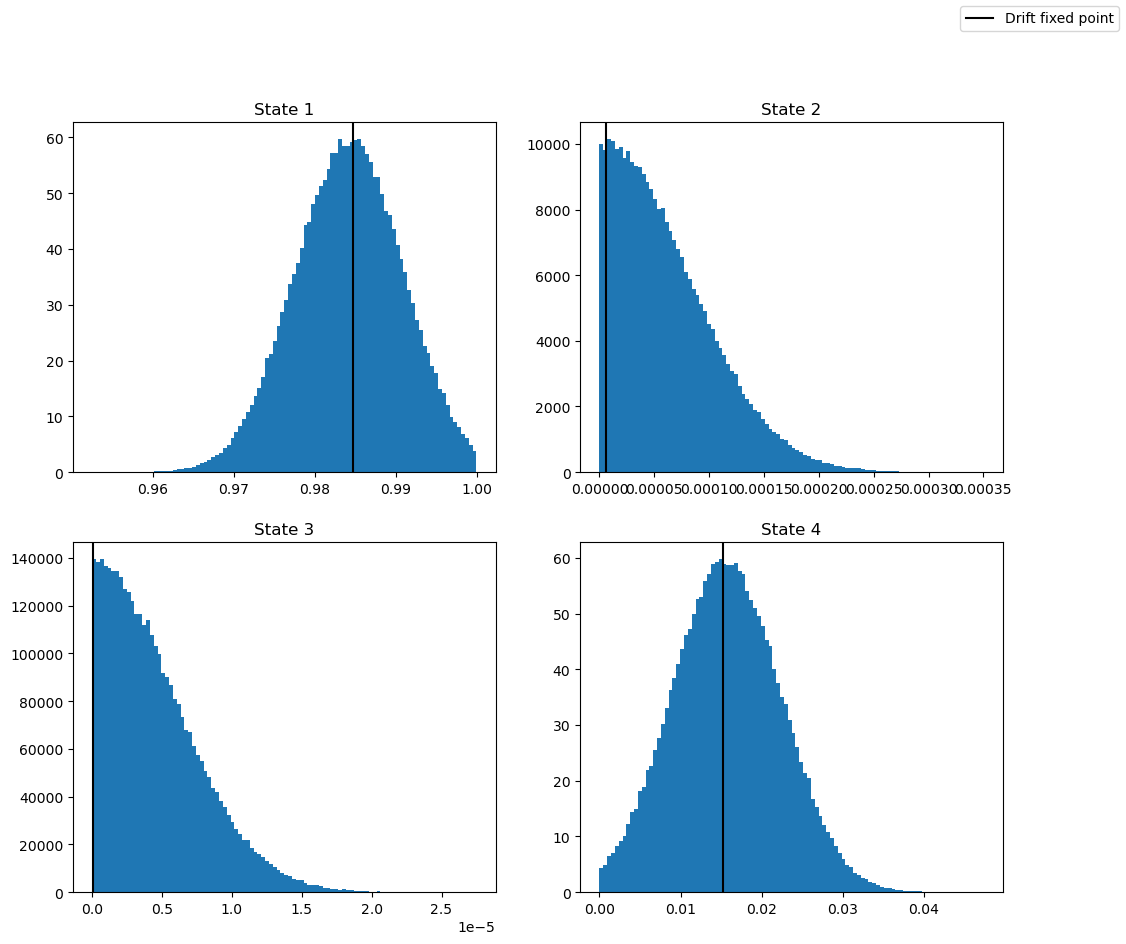

In [11]:
fig, ax = plt.subplots(2,2, figsize=(12,10))
ax[0,0].hist(stationary[0, bdy_idx], bins=100, density=True)
ax[0,0].axvline(x=fixed_pts[1]['fp'][0], color='k', label="Drift fixed point")
ax[0,0].set_title("State 1")

ax[0,1].hist(stationary[1, bdy_idx], bins=100, density=True)
ax[0,1].axvline(x=fixed_pts[1]['fp'][1], color='k')
ax[0,1].set_title("State 2")

ax[1,0].hist(stationary[2, bdy_idx], bins=100, density=True)
ax[1,0].axvline(x=fixed_pts[1]['fp'][2], color='k')
ax[1,0].set_title("State 3")

ax[1,1].hist(1 - stationary[:, bdy_idx].sum(axis=0), bins=100, density=True)
ax[1,1].axvline(x=1-fixed_pts[1]['fp'].sum(), color='k')
ax[1,1].set_title("State 4")
fig.legend()
plt.show()

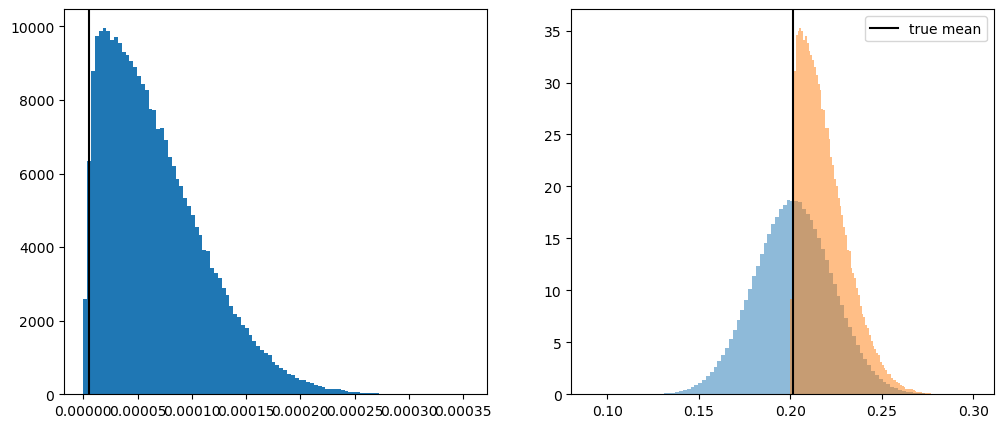

In [12]:
cp_no_boundary = (cs + kr * cjsr * stationary[1:].sum(axis=0)) / (1 + kr * stationary[1:].sum(axis=0))
cp_boundary = (cs + kr * cjsr * stationary[1:, bdy_idx].sum(axis=0)) / (1 + kr * stationary[1:, bdy_idx].sum(axis=0))
cp_true = (cs + kr * cjsr * np.arange(0, len(log_pi_tr)) / N) / (1 + kr * np.arange(0, len(log_pi_tr)) / N)

true_mean = (cp_true * np.exp(log_pi_tr)).sum()

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].hist(stationary[1, bdy_idx] + stationary[2, bdy_idx], bins=100, density=True)
ax[0].axvline(x=fixed_pts[1]['fp'][1] + fixed_pts[1]['fp'][2], color='k')

ax[1].hist(cp_no_boundary, density=True, bins=100, alpha=0.5)
ax[1].hist(cp_boundary, density=True, bins=100, alpha=0.5)
ax[1].axvline(x=true_mean, color='k', label="true mean")
ax[1].legend()
plt.show()

In [13]:
true_std = np.sqrt((cp_true**2 * np.exp(log_pi_tr)).sum() - true_mean**2)
print(f"Mean no boundary imposed: {cp_no_boundary.mean()},  relative error: {(cp_no_boundary.mean() - true_mean) / true_mean}")
print(f"Mean boundary imposed: {cp_boundary.mean()}, relative error: {(cp_boundary.mean() - true_mean) / true_mean}")
print(f"\nStd. dev no boundary imposed: {cp_no_boundary.std()},  relative error: {(cp_no_boundary.std() - true_std) / true_std}")
print(f"Std. dev boundary imposed: {cp_boundary.std()}, relative error: {(cp_boundary.std() - true_std) / true_std}")

Mean no boundary imposed: 0.20157145152947487,  relative error: -0.0001832479387235848
Mean boundary imposed: 0.21880638537206828, relative error: 0.08530393512089239

Std. dev no boundary imposed: 0.021352779091338783,  relative error: -0.011577699115550306
Std. dev boundary imposed: 0.013127259048663008, relative error: -0.392337852713102


In [19]:
N = 100
init_gillespie = np.array([N, 0, 0, 0])
init_diff = np.array([1.0, 0, 0, 0])
cs = 0.2
cjsr = 1100.

eps = 1 / np.sqrt(N)

In [23]:
ts_d, ryr_d = ryr_diffusion(init_diff, cs, cjsr, eps, params, 4_000_000, 1e-3)
ts_d_, ryr_d_ = ryr_diffusion_v2(init_diff, cs, cjsr, eps, params, 4_000_000, 1e-3)

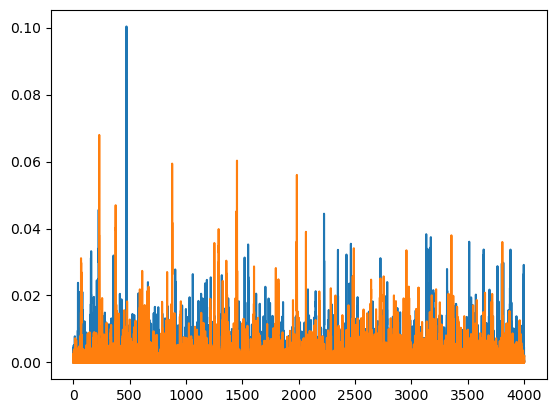

In [24]:
plt.plot(ts_d[::100], ryr_d[::100, 1:-1].sum(axis=-1))
plt.plot(ts_d_[::100], ryr_d_[::100, 1:-1].sum(axis=-1))
plt.show()

In [26]:
#ts_d, ryr_d = ryr_diffusion(init_diff, cs, cjsr, eps, params, 4_000_000, 1e-3)
#ts_d_, ryr_d_ = ryr_diffusion_relaxed_bdy(init_diff, cs, cjsr, eps, params, 4_000_000, 1e-3)
ts_d_nb, ryr_d_nb = ryr_diffusion_no_bdy(init_diff, cs, cjsr, eps, params, 4_000_000, 1e-3)
ts_g, ryr_g = ryr_gillespie(init_gillespie, cs, cjsr, params, nstep=500)

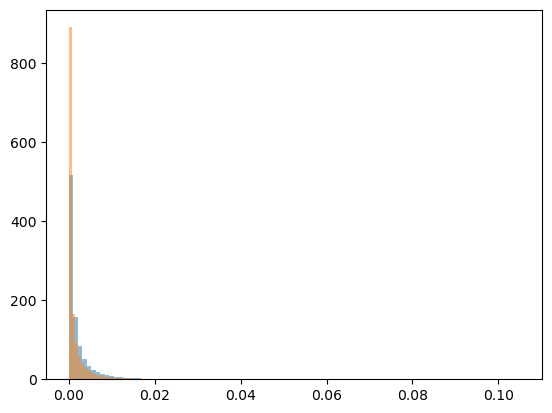

In [34]:
plt.hist(ryr_d[:, 1:-1].sum(axis=-1), bins=100, density=True, alpha=0.5)
plt.hist(ryr_d_[:, 1:-1].sum(axis=-1), bins=100, density=True, alpha=0.5)
#plt.hist(ryr_d_nb[:, 1:-1].sum(axis=-1), bins=100, density=True, alpha=0.5)
plt.show()

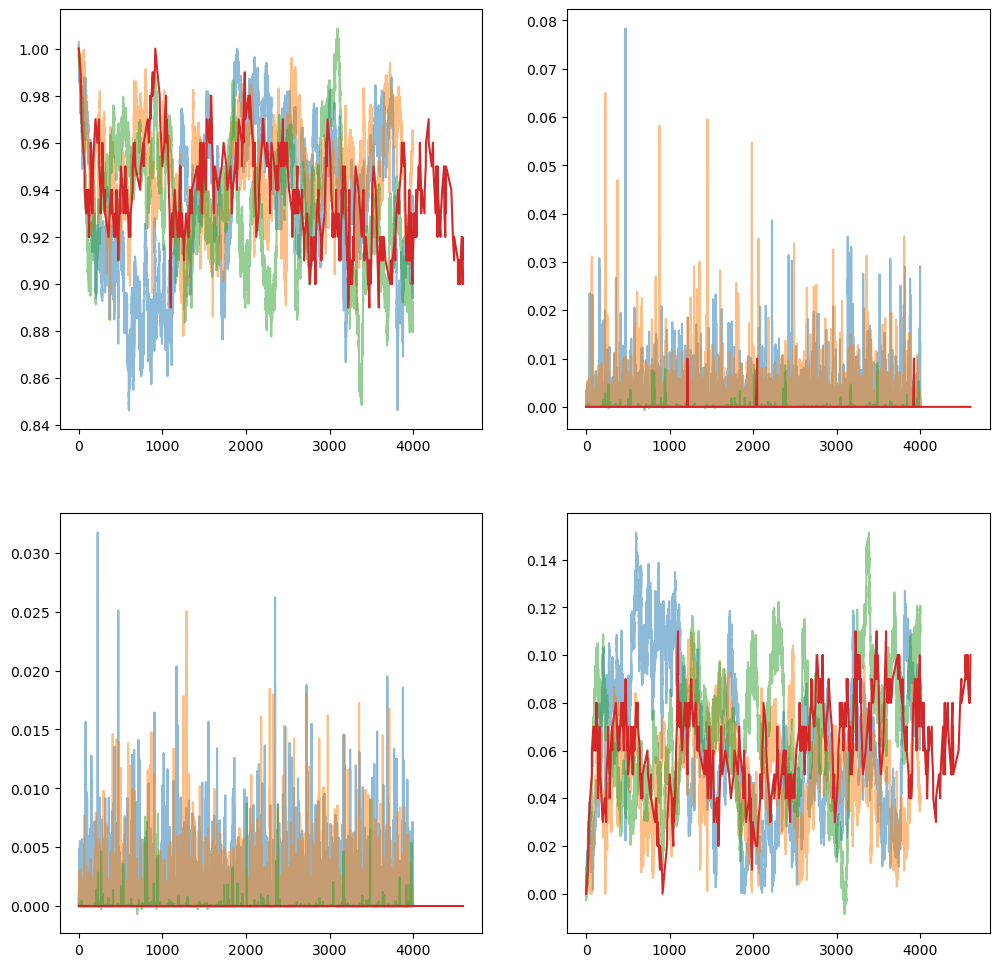

In [27]:
fig, ax = plt.subplots(2,2, figsize=(12,12))
ax[0,0].plot(ts_d[::100], ryr_d[::100, 0], alpha=0.5)
ax[0,0].plot(ts_d_[::100], ryr_d_[::100, 0], alpha=0.5)
ax[0,0].plot(ts_d_nb[::100], ryr_d_nb[::100, 0], alpha=0.5)
ax[0,0].plot(ts_g, ryr_g[:, 0] / N)

ax[0,1].plot(ts_d[::100], ryr_d[::100, 1], alpha=0.5)
ax[0,1].plot(ts_d_[::100], ryr_d_[::100, 1], alpha=0.5)
ax[0,1].plot(ts_d_nb[::100], ryr_d_nb[::100, 1], alpha=0.5)
ax[0,1].plot(ts_g, ryr_g[:, 1] / N)

ax[1,0].plot(ts_d[::100], ryr_d[::100, 2], alpha=0.5)
ax[1,0].plot(ts_d_[::100], ryr_d_[::100, 2], alpha=0.5)
ax[1,0].plot(ts_d_nb[::100], ryr_d_nb[::100, 1], alpha=0.5)
ax[1,0].plot(ts_g, ryr_g[:, 2] / N)

ax[1,1].plot(ts_d[::100], ryr_d[::100, 3], alpha=0.5)
ax[1,1].plot(ts_d_[::100], ryr_d_[::100, 3], alpha=0.5)
ax[1,1].plot(ts_d_nb[::100], ryr_d_nb[::100, 3], alpha=0.5)
ax[1,1].plot(ts_g, ryr_g[:, 3] / N)
plt.show()

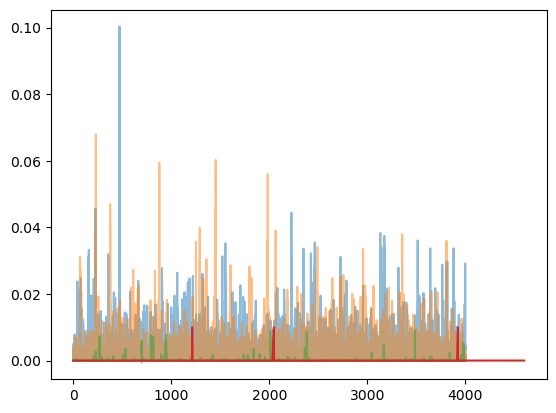

In [28]:
plt.plot(ts_d[::100], ryr_d[::100, 1] + ryr_d[::100, 2], alpha=0.5)
plt.plot(ts_d_[::100], ryr_d_[::100, 1] + ryr_d_[::100, 2], alpha=0.5)
plt.plot(ts_d_nb[::100], ryr_d_nb[::100, 1] + ryr_d_nb[::100, 2], alpha=0.5)
plt.plot(ts_g, (ryr_g[:, 1] + ryr_g[:, 2]) / N)
plt.show()

In [29]:
kr = params.tau_ps * params.Jmax / params.vp
cp_g = (cs + cjsr * kr * (ryr_g[:, 1] + ryr_g[:, 2]) / N) / (1 + kr * (ryr_g[:, 1] + ryr_g[:, 2]) / N)
cp_d = (cs + cjsr * kr * (ryr_d[:, 1] + ryr_d[:, 2])) / (1 + kr * (ryr_d[:, 1] + ryr_d[:, 2]))
cp_d_ = (cs + cjsr * kr * (ryr_d_[:, 1] + ryr_d_[:, 2])) / (1 + kr * (ryr_d_[:, 1] + ryr_d_[:, 2]))
cp_d_nb = (cs + cjsr * kr * np.clip(ryr_d_nb[:, 1] + ryr_d_nb[:, 2], 0, 1)) / (1 + kr * np.clip(ryr_d_nb[:, 1] + ryr_d_nb[:, 2], 0, 1))

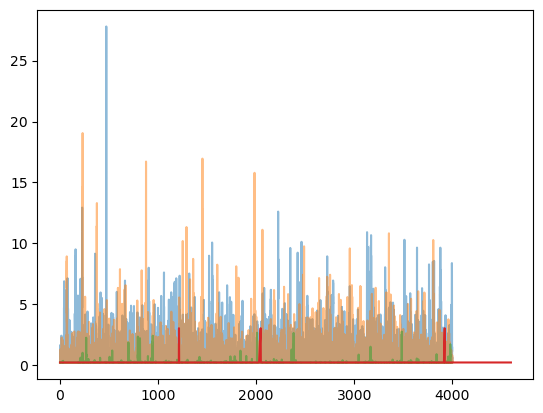

In [30]:
plt.plot(ts_d[::100], cp_d[::100], alpha=0.5)
plt.plot(ts_d_[::100], cp_d_[::100], alpha=0.5)
plt.plot(ts_d_nb[::100], cp_d_nb[::100], alpha=0.5)
plt.plot(ts_g, cp_g)
plt.show()

In [35]:
def sigma12(r1_range, r2_range, r3_range, cs, cj, params: RestrepoParams, num=100):
    r1_lin = np.linspace(r1_range[0], r1_range[1], num=num)
    r2_lin = np.linspace(r2_range[0], r2_range[1], num=num)
    r3_lin = np.linspace(r3_range[0], r3_range[1], num=num)
    r1, r2, r3 = np.meshgrid(r1_lin, r2_lin, r3_lin)
    
    kr = params.Jmax * params.tau_ps / params.vp
    cp = np.where((r2 + r3) > 0.0, (cs + (r1 + r2) * kr * cj) / (1.0 + kr * (r2 + r3)), cs)
    k12 = params.Ku * cp**2
    k21 = 1 / params.tau_c

    return r1_lin, r2_lin, r3_lin, k12 * r1 + k21 * r2

In [58]:
r1, r2, r3, s12 = sigma12((0.8, 1.1), (-0.05, 0.05), (-0.01, 0.01), 0.2, 1100, params)

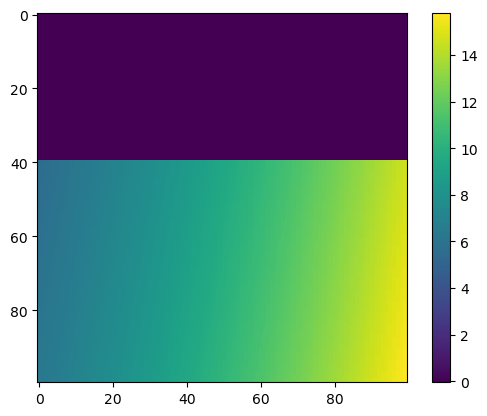

In [60]:
plt.imshow(s12[..., -1])
plt.colorbar()
plt.show()

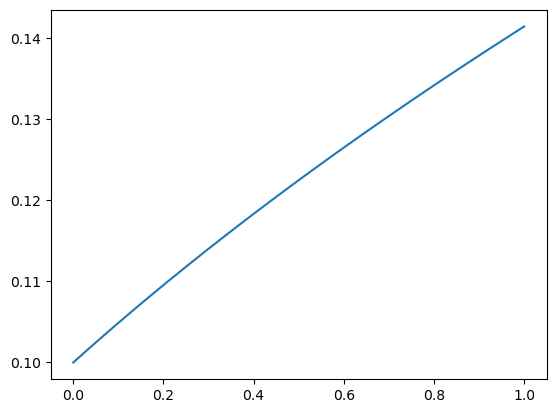

In [66]:
alpha = 0.01
beta = 0.02
x = np.linspace(0, 1, num=1000)
plt.plot(x, np.sqrt(alpha * (1 - x) + beta * x))
plt.show()